# Fluxo NDVI - Base e Nova Regiao

Notebook executa NDVI localmente com selecao robusta de raster, validacao de bandas, tratamento de valores invalidos e exportacao de resultados.


In [1]:
from pathlib import Path
from datetime import datetime
import csv
import re

import numpy as np
import matplotlib.pyplot as plt
import rasterio


In [2]:
# Configuracao
RUN_BASE = True
RUN_NEW_REGION = False  # Ative apos fornecer um segundo TIFF ou NEW_REGION_RASTER_PATH

BASE_RASTER_PATH = None          # Exemplo: r"C:/dados/cena_base.tif"
NEW_REGION_RASTER_PATH = None    # Exemplo: r"C:/dados/cena_nova_regiao.tif"

# Override manual de bandas (indice 1-based). Deixe None para auto-deteccao por descricao.
RED_BAND_INDEX = None
NIR_BAND_INDEX = None

# Se descricoes nao existirem e overrides forem None, este fallback usa padrao Sentinel-2.
ASSUME_SENTINEL_FALLBACK_IF_NO_DESC = False

cwd = Path.cwd()
if (cwd / "src").exists():
    PROJECT_DIR = cwd
elif (cwd / "NDVI_implementation" / "src").exists():
    PROJECT_DIR = cwd / "NDVI_implementation"
else:
    raise FileNotFoundError("Nao foi possivel encontrar a pasta src/. Abra este notebook na raiz do projeto ou em NDVI_implementation/.")

SRC_DIR = PROJECT_DIR / "src"
OUTPUT_DIR = PROJECT_DIR / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_DIR: {PROJECT_DIR}")
print(f"SRC_DIR: {SRC_DIR}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")


PROJECT_DIR: c:\Users\renan\OneDrive\Documentos\TechGuard\ProjetoSemana5\NDVI_implementation
SRC_DIR: c:\Users\renan\OneDrive\Documentos\TechGuard\ProjetoSemana5\NDVI_implementation\src
OUTPUT_DIR: c:\Users\renan\OneDrive\Documentos\TechGuard\ProjetoSemana5\NDVI_implementation\output


In [3]:
def extract_date_from_name(path: Path):
    """Extrai data do nome do arquivo (YYYY-MM-DD ou YYYYMMDD)."""
    name = path.stem
    patterns = [
        r"(20\d{2})[-_](0[1-9]|1[0-2])[-_](0[1-9]|[12]\d|3[01])",
        r"(20\d{2})(0[1-9]|1[0-2])(0[1-9]|[12]\d|3[01])",
    ]
    for pattern in patterns:
        m = re.search(pattern, name)
        if m:
            year, month, day = m.groups()
            try:
                return datetime(int(year), int(month), int(day)).date()
            except ValueError:
                return None
    return None


def discover_tifs(src_dir: Path):
    """Retorna TIFFs em src_dir ordenados por nome para listagem estavel."""
    return sorted(src_dir.glob("*.tif"), key=lambda p: p.name.lower())


def choose_by_mtime_then_name(paths):
    if not paths:
        raise ValueError("Nenhum candidato TIFF disponivel.")
    mtimes = [(p, p.stat().st_mtime) for p in paths]
    max_mtime = max(m for _, m in mtimes)
    top = [p for p, m in mtimes if m == max_mtime]
    return sorted(top, key=lambda p: p.name.lower())[0]


def select_main_tif(tif_files):
    """
    Regra de selecao:
    1) Data mais recente no nome do arquivo
    2) Fallback para mtime mais recente
    3) Desempate por ordem alfabetica
    """
    if not tif_files:
        raise FileNotFoundError(f"Nenhum .tif encontrado em {SRC_DIR}")

    dated = []
    for tif in tif_files:
        date_in_name = extract_date_from_name(tif)
        if date_in_name is not None:
            dated.append((tif, date_in_name))

    if dated:
        latest_date = max(d for _, d in dated)
        same_date = [p for p, d in dated if d == latest_date]
        chosen = choose_by_mtime_then_name(same_date)
        reason = f"selecionado pela data mais recente no nome ({latest_date})"
        return chosen, reason

    chosen = choose_by_mtime_then_name(tif_files)
    reason = "selecionado por mtime mais recente (sem data valida no nome)"
    return chosen, reason


def select_new_region_tif(tif_files, base_tif: Path):
    """Escolhe automaticamente um TIFF de nova regiao diferente do base."""
    base_resolved = base_tif.resolve()
    candidates = [p for p in tif_files if p.resolve() != base_resolved]
    if not candidates:
        raise ValueError(
            "RUN_NEW_REGION=True, mas nao foi encontrado segundo TIFF em src/. "
            "Adicione outro TIFF ou defina NEW_REGION_RASTER_PATH explicitamente."
        )
    return select_main_tif(candidates)


In [4]:
def resolve_band_indexes(src, red_override=None, nir_override=None, assume_sentinel=False):
    """Resolve indices de banda Red/NIR (1-based), priorizando descricao das bandas."""
    descriptions = tuple((d or "").strip().upper() for d in src.descriptions)
    print(f"Descricoes de banda: {descriptions}")

    desc_to_index = {}
    for idx, desc in zip(src.indexes, descriptions):
        if desc and desc not in desc_to_index:
            desc_to_index[desc] = idx

    if "B4" in desc_to_index and "B8" in desc_to_index:
        red_idx, nir_idx = desc_to_index["B4"], desc_to_index["B8"]
        print(f"Usando descricao -> Red(B4)={red_idx}, NIR(B8)={nir_idx}")
        return red_idx, nir_idx

    if (red_override is None) ^ (nir_override is None):
        raise ValueError("Defina RED_BAND_INDEX e NIR_BAND_INDEX juntos, ou deixe ambos como None.")

    if red_override is not None and nir_override is not None:
        if not (1 <= red_override <= src.count and 1 <= nir_override <= src.count):
            raise ValueError(f"Indices manuais fora do intervalo. Disponivel: 1..{src.count}")
        print(f"Usando override manual -> Red={red_override}, NIR={nir_override}")
        return red_override, nir_override

    if assume_sentinel:
        print("Descricoes ausentes. Usando fallback Sentinel: Red=3 (B4), NIR=7 (B8).")
        return 3, 7

    raise ValueError(
        "Nao foi possivel auto-detectar B4/B8 pelas descricoes. "
        "Defina RED_BAND_INDEX/NIR_BAND_INDEX ou habilite ASSUME_SENTINEL_FALLBACK_IF_NO_DESC."
    )


def compute_ndvi(raster_path: Path):
    """Calcula NDVI com tratamento robusto de invalidos e retorna NDVI + estatisticas."""
    with rasterio.open(raster_path) as src:
        if src.crs is None:
            raise ValueError(f"Raster sem CRS: {raster_path}")

        print(f"\nRaster: {raster_path}")
        print(f"CRS: {src.crs}")
        print(f"Quantidade de bandas: {src.count}")
        print(f"Nodata: {src.nodata}")

        red_idx, nir_idx = resolve_band_indexes(
            src,
            red_override=RED_BAND_INDEX,
            nir_override=NIR_BAND_INDEX,
            assume_sentinel=ASSUME_SENTINEL_FALLBACK_IF_NO_DESC,
        )

        # masked=True respeita nodata e mascaras internas do raster.
        red = src.read(red_idx, masked=True).astype("float32")
        nir = src.read(nir_idx, masked=True).astype("float32")

    red_data = red.filled(np.nan)
    nir_data = nir.filled(np.nan)

    valid_inputs = np.isfinite(red_data) & np.isfinite(nir_data)
    denominator = nir_data + red_data

    ndvi = np.full(red_data.shape, np.nan, dtype="float32")
    np.divide(
        nir_data - red_data,
        denominator,
        out=ndvi,
        where=valid_inputs & (denominator != 0),
    )

    # Remove nao finitos e garante dominio NDVI.
    ndvi[~np.isfinite(ndvi)] = np.nan
    np.clip(ndvi, -1.0, 1.0, out=ndvi)

    valid = np.isfinite(ndvi)
    if not np.any(valid):
        raise ValueError(f"Nao ha pixels NDVI validos para o raster: {raster_path}")

    stats = {
        "min": float(np.nanmin(ndvi)),
        "max": float(np.nanmax(ndvi)),
        "mean": float(np.nanmean(ndvi)),
        "median": float(np.nanmedian(ndvi)),
        "std": float(np.nanstd(ndvi)),
        "valid_pct": float(valid.sum() / ndvi.size * 100.0),
    }

    return ndvi, stats


In [5]:
def plot_ndvi_map(ndvi, title):
    fig, ax = plt.subplots(figsize=(16, 8))
    im = ax.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.axis("off")
    cbar = fig.colorbar(im, ax=ax, orientation="horizontal", shrink=0.75, pad=0.04)
    cbar.set_label("NDVI")
    fig.tight_layout()
    return fig


def plot_ndvi_hist(ndvi, title, bins=30):
    values = ndvi[np.isfinite(ndvi)]
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.hist(values, bins=bins, color="green", edgecolor="black")
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("Valor de NDVI")
    ax.set_ylabel("Quantidade de pixels")
    fig.tight_layout()
    return fig


def save_outputs(fig_map, fig_hist, stats, prefix, output_dir: Path):
    output_dir.mkdir(parents=True, exist_ok=True)

    map_path = output_dir / f"ndvi_map_{prefix}.png"
    hist_path = output_dir / f"ndvi_hist_{prefix}.png"
    stats_path = output_dir / f"ndvi_stats_{prefix}.csv"

    fig_map.savefig(map_path, dpi=200, bbox_inches="tight")
    fig_hist.savefig(hist_path, dpi=200, bbox_inches="tight")

    with open(stats_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["metrica", "valor"])
        for k, v in stats.items():
            writer.writerow([k, v])

    return map_path, hist_path, stats_path


TIFFs detectados em src/:
- QE_2024-09-20.tif

Raster base: QE_2024-09-20.tif (selecionado pela data mais recente no nome (2024-09-20))

Raster: c:\Users\renan\OneDrive\Documentos\TechGuard\ProjetoSemana5\NDVI_implementation\src\QE_2024-09-20.tif
CRS: EPSG:32722
Quantidade de bandas: 10
Nodata: None
Descricoes de banda: ('B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12')
Usando descricao -> Red(B4)=3, NIR(B8)=7
Estatisticas NDVI (base):
  min: -1.0
  max: 1.0
  mean: 0.2817752957344055
  median: 0.23873570561408997
  std: 0.2211463302373886
  valid_pct: 93.04368086746938


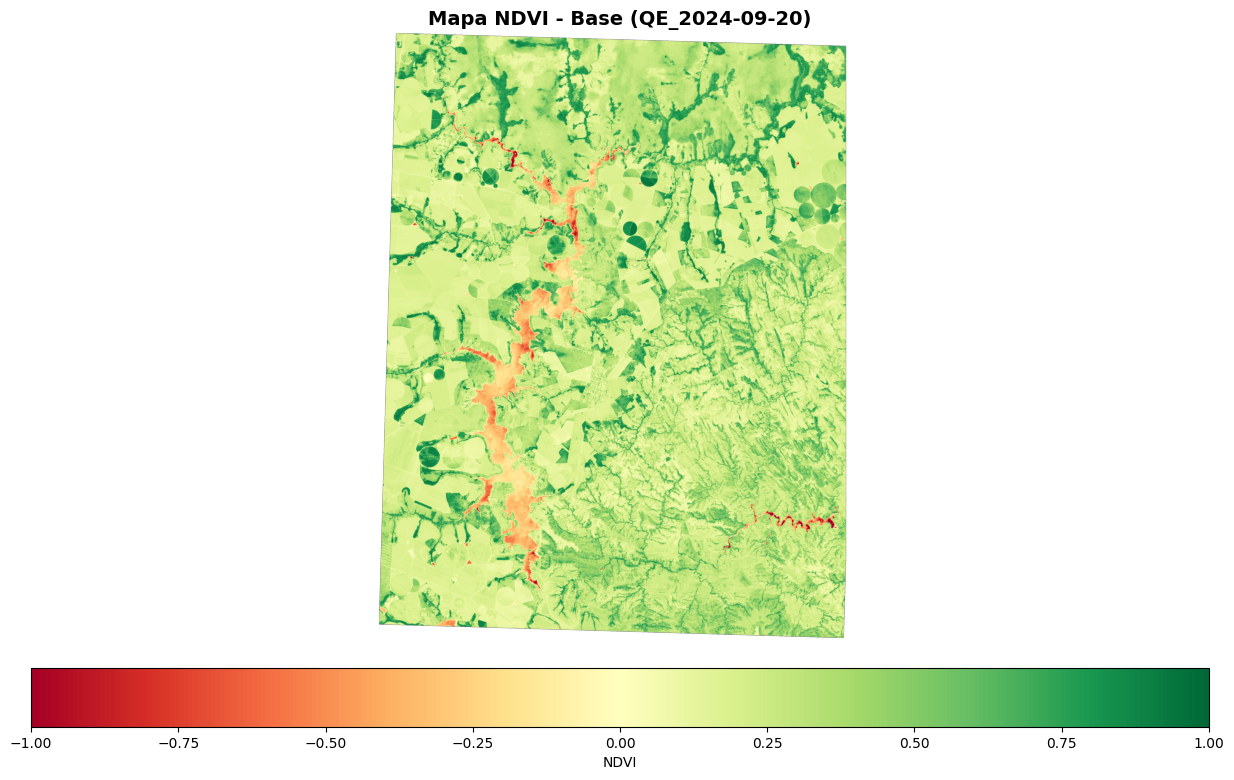

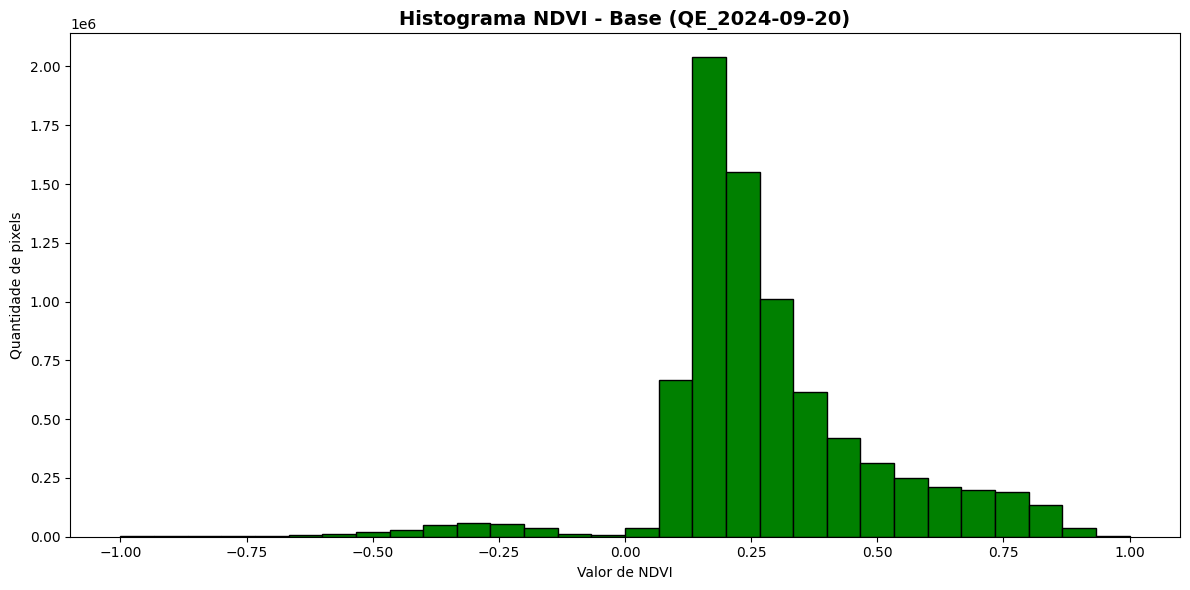

RUN_NEW_REGION esta False. Ative apos adicionar um segundo TIFF ou definir NEW_REGION_RASTER_PATH.

Arquivos gerados:
- c:\Users\renan\OneDrive\Documentos\TechGuard\ProjetoSemana5\NDVI_implementation\output\ndvi_map_base_QE_2024-09-20.png
- c:\Users\renan\OneDrive\Documentos\TechGuard\ProjetoSemana5\NDVI_implementation\output\ndvi_hist_base_QE_2024-09-20.png
- c:\Users\renan\OneDrive\Documentos\TechGuard\ProjetoSemana5\NDVI_implementation\output\ndvi_stats_base_QE_2024-09-20.csv


In [6]:
tif_files = discover_tifs(SRC_DIR)
print("TIFFs detectados em src/:")
for tif in tif_files:
    print(f"- {tif.name}")

if not tif_files:
    raise FileNotFoundError(f"Nenhum arquivo TIFF encontrado em {SRC_DIR}")

if BASE_RASTER_PATH is not None:
    base_tif = Path(BASE_RASTER_PATH).expanduser().resolve()
    base_reason = "selecionado via BASE_RASTER_PATH"
else:
    base_tif, base_reason = select_main_tif(tif_files)

if not base_tif.exists():
    raise FileNotFoundError(f"Raster base nao encontrado: {base_tif}")

print(f"\nRaster base: {base_tif.name} ({base_reason})")
generated_files = []

if RUN_BASE:
    ndvi_base, stats_base = compute_ndvi(base_tif)
    print("Estatisticas NDVI (base):")
    for key, value in stats_base.items():
        print(f"  {key}: {value}")

    fig_map_base = plot_ndvi_map(ndvi_base, f"Mapa NDVI - Base ({base_tif.stem})")
    fig_hist_base = plot_ndvi_hist(ndvi_base, f"Histograma NDVI - Base ({base_tif.stem})")

    saved = save_outputs(fig_map_base, fig_hist_base, stats_base, f"base_{base_tif.stem}", OUTPUT_DIR)
    generated_files.extend(saved)
    plt.show()
else:
    print("RUN_BASE esta False.")

if RUN_NEW_REGION:
    if NEW_REGION_RASTER_PATH is not None:
        new_tif = Path(NEW_REGION_RASTER_PATH).expanduser().resolve()
        new_reason = "selecionado via NEW_REGION_RASTER_PATH"
    else:
        new_tif, new_reason = select_new_region_tif(tif_files, base_tif)

    if not new_tif.exists():
        raise FileNotFoundError(f"Raster da nova regiao nao encontrado: {new_tif}")

    if new_tif.resolve() == base_tif.resolve():
        raise ValueError("Raster base e raster da nova regiao sao o mesmo arquivo. Defina NEW_REGION_RASTER_PATH ou adicione outro TIFF.")

    print(f"\nRaster nova regiao: {new_tif.name} ({new_reason})")

    ndvi_new, stats_new = compute_ndvi(new_tif)
    print("Estatisticas NDVI (nova regiao):")
    for key, value in stats_new.items():
        print(f"  {key}: {value}")

    fig_map_new = plot_ndvi_map(ndvi_new, f"Mapa NDVI - Nova Regiao ({new_tif.stem})")
    fig_hist_new = plot_ndvi_hist(ndvi_new, f"Histograma NDVI - Nova Regiao ({new_tif.stem})")

    saved = save_outputs(fig_map_new, fig_hist_new, stats_new, f"new_{new_tif.stem}", OUTPUT_DIR)
    generated_files.extend(saved)
    plt.show()
else:
    print("RUN_NEW_REGION esta False. Ative apos adicionar um segundo TIFF ou definir NEW_REGION_RASTER_PATH.")

print("\nArquivos gerados:")
for f in generated_files:
    print(f"- {f}")


## Resumo do NDVI

O NDVI e calculado por:

`NDVI = (NIR - Red) / (NIR + Red)`

Para Sentinel-2, o padrao e `NIR = B8` e `Red = B4`.
Este notebook mascara pixels invalidos, evita divisao por zero e exporta mapa, histograma e estatisticas.
